# 서울 상권정보 분석

---
## 1단계: 라이브러리 불러오기 및 환경 설정

분석에 필요한 도구(라이브러리)를 먼저 불러옵니다.


In [1]:
import pandas as pd          
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

---
## 2단계: 데이터 불러오기

CSV 파일을 DataFrame으로 불러옵니다.

```
pd.read_csv('파일경로', encoding='인코딩방식')
```

- `encoding='utf-8'` 또는  `'cp949'` 등 한글이 포함된 파일을 제대로 읽기 위한 설정

In [4]:
df = pd.read_csv('서울상권정보.csv')  # 여러분이 공공데이터에서 다운 받은 데이터파일, 없으면 사캠 데이터로 하세요!
df.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
1,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,용산구,남영동,동자동,126.972240,37.552803
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
3,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,노원구,상계5동,상계동,127.071218,37.660715
4,MA010120220810170381,금빛주얼리,소매,시계·귀금속 소매,시계/귀금속 소매업,종로구,종로1.2.3.4가동,묘동,126.991861,37.572331


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534978 entries, 0 to 534977
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상가업소번호    534978 non-null  object 
 1   상호명       534978 non-null  object 
 2   상권업종대분류명  534978 non-null  object 
 3   상권업종중분류명  534978 non-null  object 
 4   상권업종소분류명  534978 non-null  object 
 5   시군구명      534978 non-null  object 
 6   행정동명      534978 non-null  object 
 7   법정동명      534978 non-null  object 
 8   경도        534978 non-null  float64
 9   위도        534978 non-null  float64
dtypes: float64(2), object(8)
memory usage: 40.8+ MB


In [6]:
df.columns

Index(['상가업소번호', '상호명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시군구명', '행정동명',
       '법정동명', '경도', '위도'],
      dtype='object')

- 이번 분석에서 주로 사용할 핵심 열들만 선택

In [7]:
cols = ['상가업소번호', '상호명','상권업종대분류명','상권업종중분류명',
        '상권업종소분류명', '시군구명', '행정동명', '법정동명', '경도', '위도']

In [8]:
df[cols]

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
1,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,용산구,남영동,동자동,126.972240,37.552803
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
3,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,노원구,상계5동,상계동,127.071218,37.660715
4,MA010120220810170381,금빛주얼리,소매,시계·귀금속 소매,시계/귀금속 소매업,종로구,종로1.2.3.4가동,묘동,126.991861,37.572331
...,...,...,...,...,...,...,...,...,...,...
534973,MA0106202511A1072506,살림,소매,기타 상품 소매,그 외 기타 상품 전문 소매업,송파구,잠실2동,잠실동,127.084186,37.512087
534974,MA0106202511A2270156,연막창건대,음식,한식,곱창 전골/구이,광진구,화양동,화양동,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,음식,한식,국/탕/찌개류,동대문구,장안2동,장안동,127.070371,37.579807
534976,MA0106202511A2056843,만월다방,음식,비알코올,카페,마포구,서강동,상수동,126.925497,37.545062


In [9]:
df = df[cols]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534978 entries, 0 to 534977
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상가업소번호    534978 non-null  object 
 1   상호명       534978 non-null  object 
 2   상권업종대분류명  534978 non-null  object 
 3   상권업종중분류명  534978 non-null  object 
 4   상권업종소분류명  534978 non-null  object 
 5   시군구명      534978 non-null  object 
 6   행정동명      534978 non-null  object 
 7   법정동명      534978 non-null  object 
 8   경도        534978 non-null  float64
 9   위도        534978 non-null  float64
dtypes: float64(2), object(8)
memory usage: 40.8+ MB


---
## 3단계: 결측치(빈 값) 확인 및 처리

데이터에 비어있는 값(NaN: Not a Number)이 있는지 확인합니다.

- `isnull()`: 각 값이 빈 값인지 True/False로 반환
- `sum()`: True를 1로 계산해서 열별 결측치 개수를 합산

In [11]:
df.isnull().sum()

상가업소번호      0
상호명         0
상권업종대분류명    0
상권업종중분류명    0
상권업종소분류명    0
시군구명        0
행정동명        0
법정동명        0
경도          0
위도          0
dtype: int64

---
## 4단계: 업종 대분류 분석

서울의 상가들이 어떤 업종으로 이루어져 있는지 파악합니다.

### 핵심 함수
- `unique()`: 중복 없는 고유한 값 목록 반환
- `value_counts()`: 각 값의 등장 횟수 반환 (많은 순서대로 정렬)

In [17]:
df.columns

Index(['상가업소번호', '상호명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시군구명', '행정동명',
       '법정동명', '경도', '위도'],
      dtype='object')

In [19]:
df['상권업종대분류명'].unique()

array(['음식', '시설관리·임대', '예술·스포츠', '소매', '부동산', '과학·기술', '수리·개인', '보건의료',
       '숙박', '교육'], dtype=object)

In [20]:
df['상권업종대분류명'].nunique()

10

<Axes: xlabel='상권업종대분류명'>

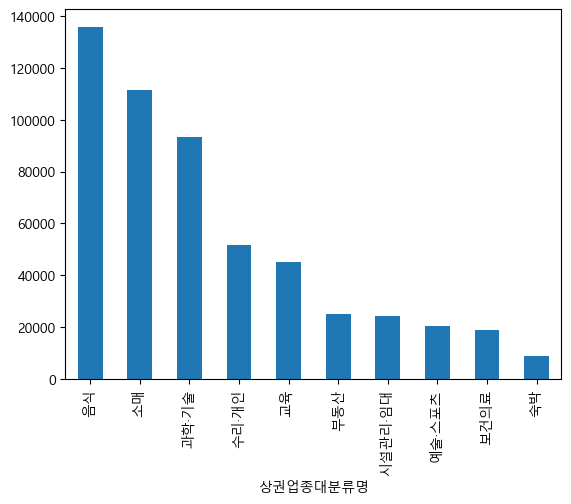

In [21]:
df['상권업종대분류명'].value_counts().plot(kind='bar')

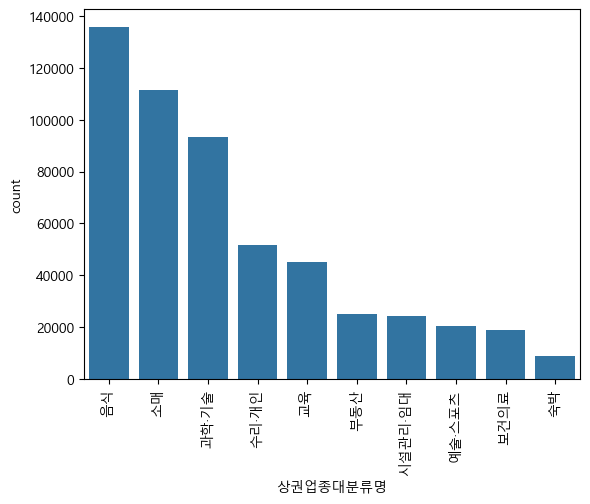

In [23]:
sns.countplot(data=df, x='상권업종대분류명',
              order=df['상권업종대분류명'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

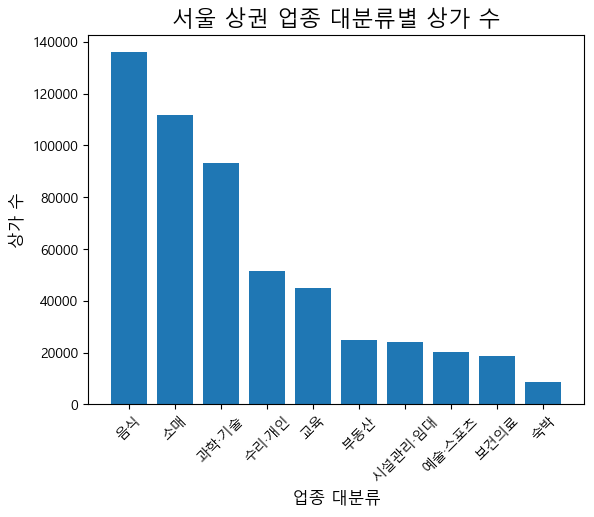

In [28]:
#plt.figure(figsize=(12, 5))          # 그래프 크기 설정 (가로12, 세로5)
plt.bar(df['상권업종대분류명'].value_counts().index, df['상권업종대분류명'].value_counts().values)
plt.title('서울 상권 업종 대분류별 상가 수', fontsize=16)
plt.xlabel('업종 대분류', fontsize=12)
plt.ylabel('상가 수', fontsize=12)
plt.xticks(rotation=45)  # x축 눈금을 45도 기울여서 표시
plt.show()

In [ ]:
df['상권업종대분류명'].value_counts().head(7).plot(
    kind=
    figsize=(6, 6),
    autopct='%1.1f%%',        # 퍼센트 표시
    startangle=90,            # 시작 각도
    counterclock=False,       # 시계 방향
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # 경계선
)

plt.title('업종 대분류 비율')
plt.ylabel('')  # 불필요한 y축 제거
plt.show()

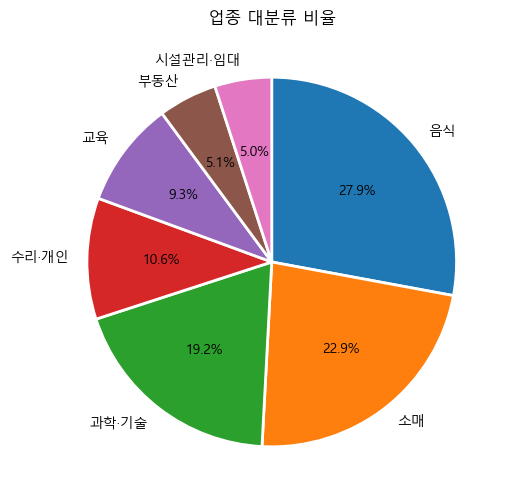

In [31]:
df['상권업종대분류명'].value_counts().head(7).plot(
    kind='pie',
    figsize=(6, 6),
    autopct='%1.1f%%',        # 퍼센트 표시
    startangle=90,            # 시작 각도
    counterclock=False,       # 시계 방향
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # 경계선
)

plt.title('업종 대분류 비율')
plt.ylabel('')  # 불필요한 y축 제거
plt.show()

---
## loc / iloc 사용법

pandas에서 데이터를 선택하는 세 가지 방법을 비교합니다.

> 조건식     
> 라벨(이름)    
> 숫자 위치(번호)    


### loc - 라벨(이름) 기준으로 선택  (label-based location)

- 행: 인덱스 번호 또는 True/False 조건
- 열: 열 이름(문자열)
- **슬라이싱 시 끝 값 포함** (iloc과 다름!)

---

문제 : 인덱스 이름이 3인 행

In [32]:
df.loc[3]

상가업소번호      MA010120220804370987
상호명                      까치노래연습장
상권업종대분류명                  예술·스포츠
상권업종중분류명                  유원지·오락
상권업종소분류명                     노래방
시군구명                         노원구
행정동명                        상계5동
법정동명                         상계동
경도                    127.071218
위도                     37.660715
Name: 3, dtype: object

In [33]:
df.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
1,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,용산구,남영동,동자동,126.972240,37.552803
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
3,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,노원구,상계5동,상계동,127.071218,37.660715
4,MA010120220810170381,금빛주얼리,소매,시계·귀금속 소매,시계/귀금속 소매업,종로구,종로1.2.3.4가동,묘동,126.991861,37.572331


In [34]:
df.loc[0:2]

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
1,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,용산구,남영동,동자동,126.972240,37.552803
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548


In [35]:
df.loc[0:2 , '상호명']

0    60계치킨암사
1     성심인력공사
2        칸토빈
Name: 상호명, dtype: object

In [37]:
df.loc[0:2 , ['상호명', '법정동명', '시군구명']]

,상호명,법정동명,시군구명
0,60계치킨암사,암사동,강동구
1,성심인력공사,동자동,용산구
2,칸토빈,공항동,강서구


### iloc - 숫자 위치(번호) 기준으로 선택 (iloc = integer location)

- 행/열 모두 **숫자 인덱스**로 지정
- **슬라이싱 시 끝 값 미포함** (Python 리스트와 동일)
- 열 이름을 몰라도 번호로 접근 가능

In [39]:
df.iloc[0:2]

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
1,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,용산구,남영동,동자동,126.972240,37.552803


In [40]:
df.iloc[0:2, 1]

0    60계치킨암사
1     성심인력공사
Name: 상호명, dtype: object

In [41]:
df.iloc[-1]

상가업소번호      MA0106202511A2286838
상호명                     에이치아이디자인
상권업종대분류명                      소매
상권업종중분류명                  장식품 소매
상권업종소분류명                    기념품점
시군구명                          중구
행정동명                         광희동
법정동명                         오장동
경도                     127.00086
위도                     37.565655
Name: 534977, dtype: object

In [42]:
df.tail()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
534973,MA0106202511A1072506,살림,소매,기타 상품 소매,그 외 기타 상품 전문 소매업,송파구,잠실2동,잠실동,127.084186,37.512087
534974,MA0106202511A2270156,연막창건대,음식,한식,곱창 전골/구이,광진구,화양동,화양동,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,음식,한식,국/탕/찌개류,동대문구,장안2동,장안동,127.070371,37.579807
534976,MA0106202511A2056843,만월다방,음식,비알코올,카페,마포구,서강동,상수동,126.925497,37.545062
534977,MA0106202511A2286838,에이치아이디자인,소매,장식품 소매,기념품점,중구,광희동,오장동,127.000860,37.565655


문제 : 상권업종대분류명이 음식인 데이터 선택 

In [43]:
df['상권업종대분류명'] == '음식'

0          True
1         False
2          True
3         False
4         False
          ...  
534973    False
534974     True
534975     True
534976     True
534977    False
Name: 상권업종대분류명, Length: 534978, dtype: bool

In [44]:
df[df['상권업종대분류명'] == '음식']

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
8,MA010120220809640417,솜노래팡팡,음식,주점,요리 주점,서초구,서초3동,서초동,127.013852,37.489862
15,MA010120220812811919,읏듬돈생삼겹살,음식,한식,돼지고기 구이/찜,성북구,석관동,석관동,127.064015,37.613579
36,MA010120220809620318,동원기사식당,음식,한식,백반/한정식,양천구,신정7동,신정동,126.866492,37.509645
...,...,...,...,...,...,...,...,...,...,...
534971,MA0106202511A0686689,오부찌,음식,한식,백반/한정식,송파구,문정2동,문정동,127.120755,37.484557
534972,MA0106202511A1878996,생각과생각사이,음식,한식,백반/한정식,용산구,용산2가동,용산동2가,126.986332,37.539624
534974,MA0106202511A2270156,연막창건대,음식,한식,곱창 전골/구이,광진구,화양동,화양동,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,음식,한식,국/탕/찌개류,동대문구,장안2동,장안동,127.070371,37.579807


In [45]:
df.loc[df['상권업종대분류명'] == '음식']

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
8,MA010120220809640417,솜노래팡팡,음식,주점,요리 주점,서초구,서초3동,서초동,127.013852,37.489862
15,MA010120220812811919,읏듬돈생삼겹살,음식,한식,돼지고기 구이/찜,성북구,석관동,석관동,127.064015,37.613579
36,MA010120220809620318,동원기사식당,음식,한식,백반/한정식,양천구,신정7동,신정동,126.866492,37.509645
...,...,...,...,...,...,...,...,...,...,...
534971,MA0106202511A0686689,오부찌,음식,한식,백반/한정식,송파구,문정2동,문정동,127.120755,37.484557
534972,MA0106202511A1878996,생각과생각사이,음식,한식,백반/한정식,용산구,용산2가동,용산동2가,126.986332,37.539624
534974,MA0106202511A2270156,연막창건대,음식,한식,곱창 전골/구이,광진구,화양동,화양동,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,음식,한식,국/탕/찌개류,동대문구,장안2동,장안동,127.070371,37.579807


In [47]:
df[df['상권업종대분류명'] == '음식']['상호명']

0         60계치킨암사
2             칸토빈
8           솜노래팡팡
15        읏듬돈생삼겹살
36         동원기사식당
           ...   
534971        오부찌
534972    생각과생각사이
534974      연막창건대
534975       하루곰탕
534976       만월다방
Name: 상호명, Length: 135884, dtype: object

In [48]:
df[df['상권업종대분류명'] == '음식'] [['상호명', '법정동명']]

,상호명,법정동명
0,60계치킨암사,암사동
2,칸토빈,공항동
8,솜노래팡팡,서초동
15,읏듬돈생삼겹살,석관동
36,동원기사식당,신정동
...,...,...
534971,오부찌,문정동
534972,생각과생각사이,용산동2가
534974,연막창건대,화양동
534975,하루곰탕,장안동


In [49]:
df.loc[df['상권업종대분류명'] == '음식', ['상호명', '법정동명']]

,상호명,법정동명
0,60계치킨암사,암사동
2,칸토빈,공항동
8,솜노래팡팡,서초동
15,읏듬돈생삼겹살,석관동
36,동원기사식당,신정동
...,...,...
534971,오부찌,문정동
534972,생각과생각사이,용산동2가
534974,연막창건대,화양동
534975,하루곰탕,장안동


---
## 5단계: 음식 업종 중분류 분석

대분류 중 '음식' 카테고리 안에서 어떤 세부 업종이 많은지 분석합니다.

### 데이터 필터링 방법
```python
df[조건]           # 조건에 맞는 행만 선택
df.loc[조건, 열]   # 조건에 맞는 행의 특정 열만 선택
```

1. 조건 만들기: 상권업종대분류명이 '음식'인지 True/False로 반환

In [50]:
df['상권업종대분류명'] == '음식'

0          True
1         False
2          True
3         False
4         False
          ...  
534973    False
534974     True
534975     True
534976     True
534977    False
Name: 상권업종대분류명, Length: 534978, dtype: bool

2. 조건에 맞는 데이터만 필터링하여 음식 업종만 보기

In [51]:
df.loc[df['상권업종대분류명'] == '음식']

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
0,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,강동구,암사2동,암사동,127.126859,37.550810
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
8,MA010120220809640417,솜노래팡팡,음식,주점,요리 주점,서초구,서초3동,서초동,127.013852,37.489862
15,MA010120220812811919,읏듬돈생삼겹살,음식,한식,돼지고기 구이/찜,성북구,석관동,석관동,127.064015,37.613579
36,MA010120220809620318,동원기사식당,음식,한식,백반/한정식,양천구,신정7동,신정동,126.866492,37.509645
...,...,...,...,...,...,...,...,...,...,...
534971,MA0106202511A0686689,오부찌,음식,한식,백반/한정식,송파구,문정2동,문정동,127.120755,37.484557
534972,MA0106202511A1878996,생각과생각사이,음식,한식,백반/한정식,용산구,용산2가동,용산동2가,126.986332,37.539624
534974,MA0106202511A2270156,연막창건대,음식,한식,곱창 전골/구이,광진구,화양동,화양동,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,음식,한식,국/탕/찌개류,동대문구,장안2동,장안동,127.070371,37.579807


3. 음식 업종에서 중분류별 상가 수

In [53]:
df_food = df[df['상권업종대분류명'] == '음식']

In [54]:
df_food['상권업종중분류명'].value_counts()

상권업종중분류명
한식         50770
기타 간이      26555
비알코올       21624
주점         15538
일식          6889
서양식         6525
중식          5200
동남아시아       1620
구내식당·뷔페     1127
기타 외국         36
Name: count, dtype: int64

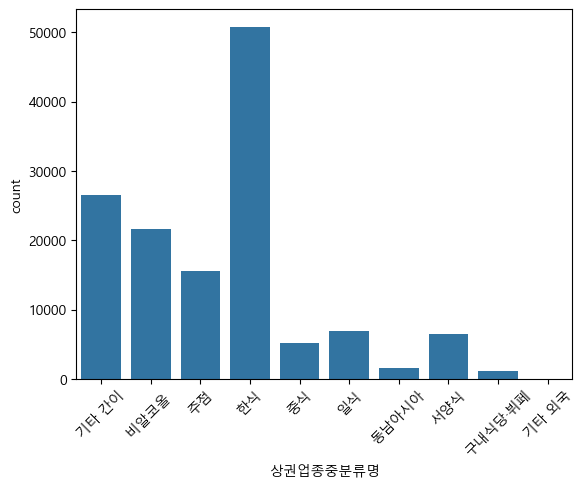

In [56]:
sns.countplot(data=df_food, x='상권업종중분류명')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.loc[ df['상권업종대분류명'] == '음식' , '상권업종중분류명'].value_counts().plot(kind='barh')

<Axes: ylabel='상권업종중분류명'>

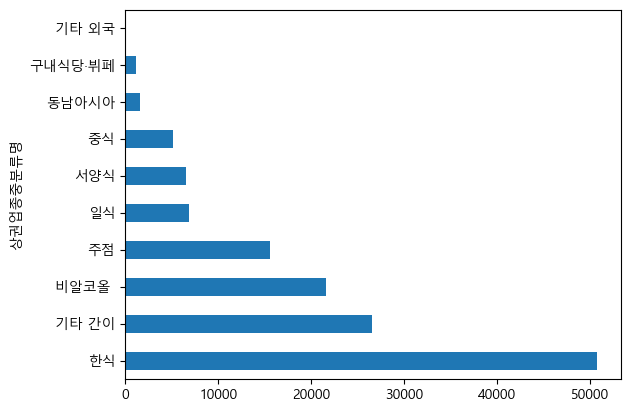

In [57]:
df.loc[ df['상권업종대분류명'] == '음식' , '상권업종중분류명'].value_counts().plot(kind='barh')

---
## 6단계: 카페 TOP 10 브랜드 분석

음식의 소분류명 중 '카페' 업종에서 어떤 브랜드가 가장 많은지 분석합니다.

In [58]:
df_food['상권업종소분류명'].unique()

array(['치킨', '카페', '요리 주점', '돼지고기 구이/찜', '백반/한정식', '횟집', '중국집', '일식 회/초밥',
       '그 외 기타 간이 음식점', '국/탕/찌개류', '해산물 구이/찜', '떡/한과', '빵/도넛', '소고기 구이/찜',
       '전/부침개', '생맥주 전문', '일반 유흥 주점', '복 요리 전문', '마라탕/훠궈', '베트남식 전문',
       '경양식', '김밥/만두/분식', '일식 면 요리', '구내식당', '피자', '냉면/밀면', '닭/오리고기 구이/찜',
       '일식 카레/돈가스/덮밥', '버거', '국수/칼국수', '아이스크림/빙수', '토스트/샌드위치/샐러드',
       '기타 동남아식 전문', '곱창 전골/구이', '기타 서양식 음식점', '파스타/스테이크', '족발/보쌈',
       '기타 한식 음식점', '무도 유흥 주점', '분류 안된 외국식 음식점', '기타 일식 음식점', '패밀리레스토랑',
       '뷔페'], dtype=object)

In [62]:
df_coffee = df_food[df_food['상권업종소분류명'] == '카페']

<Axes: xlabel='상호명'>

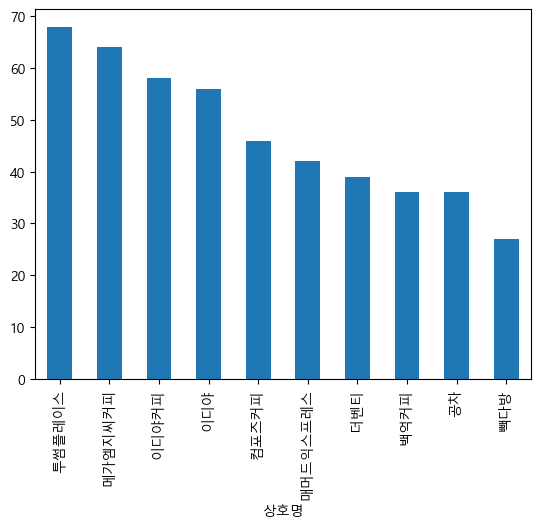

In [65]:
df_coffee['상호명'].value_counts().head(10).plot(kind='bar')

In [71]:
top10 = df_coffee['상호명'].value_counts().head(10).index

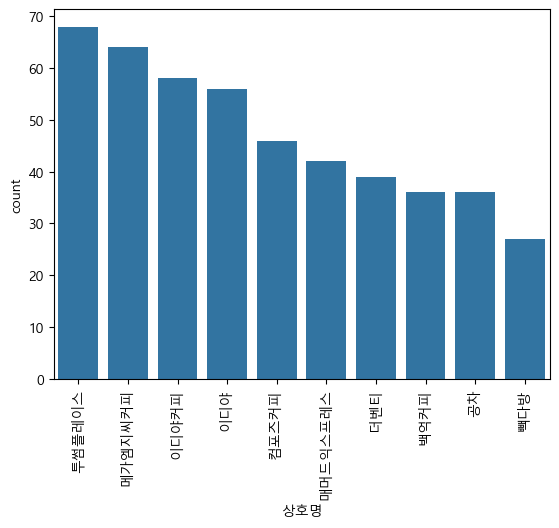

In [72]:
sns.countplot(data=df_coffee[ df_coffee['상호명'].isin(top10)], x='상호명',
              order=top10)
plt.xticks(rotation=90)
plt.show()

문제 : 투썸플레이스 와 메가엠지씨커피 

In [104]:
df_mega=df_coffee[df_coffee['상호명'].str.contains('메가')].copy()
df_mega

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
1903,MA010120220813183823,메가엠지씨커피수유,음식,비알코올,카페,강북구,수유1동,수유동,127.018013,37.630912
2964,MA010120220812507366,메가MGC커피상암사보이시티점,음식,비알코올,카페,마포구,상암동,상암동,126.888542,37.581325
3510,MA010120220809740316,메가엠지씨커피휘경주공점,음식,비알코올,카페,동대문구,장안2동,장안동,127.070394,37.580149
3704,MA010120220803674019,메가엠지씨커피강동역점,음식,비알코올,카페,강동구,길동,길동,127.135229,37.535853
5293,MA010120220803331542,메가엠지씨커피신용산역점,음식,비알코올,카페,용산구,한강로동,한강로2가,126.969996,37.531017
...,...,...,...,...,...,...,...,...,...,...
534378,MA0106202511A0885817,메가엠지씨커피역삼센터필드점,음식,비알코올,카페,강남구,역삼1동,역삼동,127.040318,37.503605
534550,MA0106202511A0887350,메가엠지씨커피,음식,비알코올,카페,동작구,신대방1동,신대방동,126.911457,37.494659
534672,MA0106202511A2428196,메가엠지씨커피,음식,비알코올,카페,동대문구,장안2동,장안동,127.071053,37.570742
534778,MA0106202511A1104238,메가엠지씨커피방배초교입구교차로점,음식,비알코올,카페,서초구,방배2동,방배동,126.985776,37.485537


In [82]:
df_ts = df_coffee[df_coffee['상호명'].str.contains('투썸플레이스')]
df_ts

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
986,MA010120220804363123,투썸플레이스중계은행,음식,비알코올,카페,노원구,중계본동,중계동,127.076975,37.649233
7155,MA010120220805117484,투썸플레이스가락시장역,음식,비알코올,카페,송파구,가락본동,가락동,127.118858,37.493136
11506,MA010120220812696762,투썸플레이스세종대학교점,음식,비알코올,카페,광진구,군자동,군자동,127.073185,37.551613
12704,MA010120220808672564,투썸플레이스답십리사거리,음식,비알코올,카페,동대문구,답십리1동,답십리동,127.056600,37.572669
13137,MA010120220811794135,투썸플레이스,음식,비알코올,카페,중구,소공동,북창동,126.977476,37.562968
...,...,...,...,...,...,...,...,...,...,...
530192,MA0106202201A1168561,투썸플레이스,음식,비알코올,카페,강남구,신사동,신사동,127.026981,37.526197
530273,MA0106202201A1168548,투썸플레이스을지트윈,음식,비알코올,카페,중구,을지로동,을지로4가,126.997329,37.566141
531803,MA0106202511A2457802,투썸플레이스신림서원역점,음식,비알코올,카페,관악구,서원동,신림동,126.933693,37.477518
532385,MA0106202511A0716596,투썸플레이스가산대성디폴리스점,음식,비알코올,카페,금천구,가산동,가산동,126.877014,37.479951


<Axes: xlabel='시군구명'>

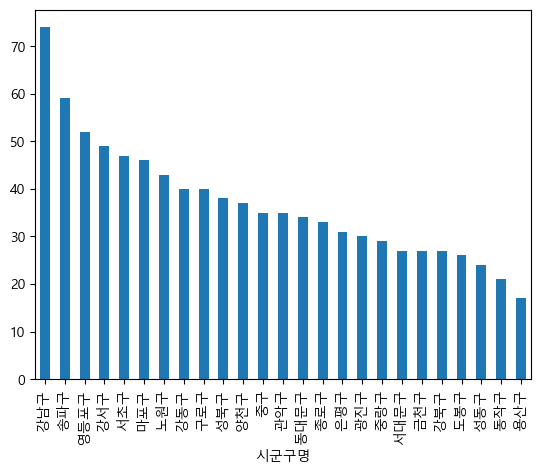

In [83]:
df_mega['시군구명'].value_counts().plot(kind='bar')

<Axes: xlabel='시군구명'>

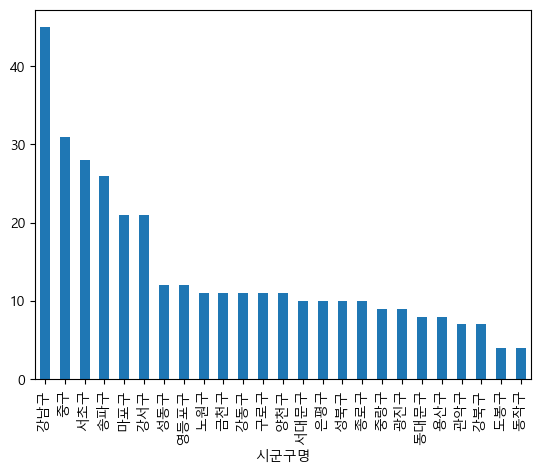

In [84]:
df_ts['시군구명'].value_counts().plot(kind='bar')

In [85]:
df_ts['시군구명'].value_counts()

시군구명
강남구     45
중구      31
서초구     28
송파구     26
마포구     21
강서구     21
성동구     12
영등포구    12
노원구     11
금천구     11
강동구     11
구로구     11
양천구     11
서대문구    10
은평구     10
성북구     10
종로구     10
중랑구      9
광진구      9
동대문구     8
용산구      8
관악구      7
강북구      7
도봉구      4
동작구      4
Name: count, dtype: int64

In [86]:
df_mega['시군구명'].value_counts()

시군구명
강남구     74
송파구     59
영등포구    52
강서구     49
서초구     47
마포구     46
노원구     43
강동구     40
구로구     40
성북구     38
양천구     37
중구      35
관악구     35
동대문구    34
종로구     33
은평구     31
광진구     30
중랑구     29
서대문구    27
금천구     27
강북구     27
도봉구     26
성동구     24
동작구     21
용산구     17
Name: count, dtype: int64

In [ ]:
df_compare=pd.DataFrame({
                        '투썸': df_ts['시군구명'].value_counts(),
                        '메가': df_mega['시군구명'].value_counts()
                        })
df_compare

In [93]:
df_compare=pd.DataFrame({
                        '투썸': df_ts['시군구명'].value_counts(),
                        '메가': df_mega['시군구명'].value_counts()
                        })
df_compare

,투썸,메가
시군구명,,
강남구,45,74
강동구,11,40
강북구,7,27
강서구,21,49
관악구,7,35
광진구,9,30
구로구,11,40
금천구,11,27
노원구,11,43


<Axes: xlabel='시군구명'>

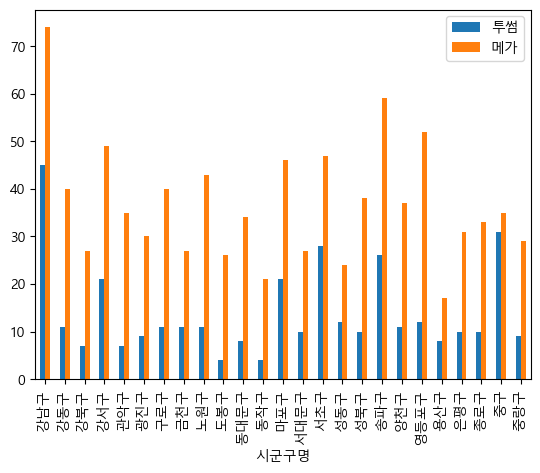

In [94]:
df_compare.plot(kind='bar')

In [95]:
df_coffee

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
2,MA010120220808205276,칸토빈,음식,비알코올,카페,강서구,공항동,공항동,126.810493,37.563548
56,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,은평구,구산동,구산동,126.916688,37.610477
75,MA010120220806903716,맹커피숍,음식,비알코올,카페,은평구,대조동,대조동,126.928818,37.610773
108,MA010120220802781563,담다,음식,비알코올,카페,동대문구,용두동,용두동,127.031631,37.581067
124,MA010120220802680776,초원,음식,비알코올,카페,동대문구,신설동,신설동,127.024498,37.576284
...,...,...,...,...,...,...,...,...,...,...
534883,MA0106202511A0380866,메가엠지씨커피서울서일초점,음식,비알코올,카페,서초구,서초1동,서초동,127.021494,37.485374
534915,MA0106202511A1330647,바나프레소,음식,비알코올,카페,은평구,대조동,대조동,126.930598,37.608747
534926,MA0106202511A0590453,다이스,음식,비알코올,카페,종로구,부암동,부암동,126.963731,37.596490
534959,MA0106202511A1593486,이디야커피르피에드점,음식,비알코올,카페,서초구,서초2동,서초동,127.025218,37.495617


In [96]:
df_mega

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
1903,MA010120220813183823,메가엠지씨커피수유,음식,비알코올,카페,강북구,수유1동,수유동,127.018013,37.630912
2964,MA010120220812507366,메가MGC커피상암사보이시티점,음식,비알코올,카페,마포구,상암동,상암동,126.888542,37.581325
3510,MA010120220809740316,메가엠지씨커피휘경주공점,음식,비알코올,카페,동대문구,장안2동,장안동,127.070394,37.580149
3704,MA010120220803674019,메가엠지씨커피강동역점,음식,비알코올,카페,강동구,길동,길동,127.135229,37.535853
5293,MA010120220803331542,메가엠지씨커피신용산역점,음식,비알코올,카페,용산구,한강로동,한강로2가,126.969996,37.531017
...,...,...,...,...,...,...,...,...,...,...
534378,MA0106202511A0885817,메가엠지씨커피역삼센터필드점,음식,비알코올,카페,강남구,역삼1동,역삼동,127.040318,37.503605
534550,MA0106202511A0887350,메가엠지씨커피,음식,비알코올,카페,동작구,신대방1동,신대방동,126.911457,37.494659
534672,MA0106202511A2428196,메가엠지씨커피,음식,비알코올,카페,동대문구,장안2동,장안동,127.071053,37.570742
534778,MA0106202511A1104238,메가엠지씨커피방배초교입구교차로점,음식,비알코올,카페,서초구,방배2동,방배동,126.985776,37.485537


In [97]:
df_ts

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도
986,MA010120220804363123,투썸플레이스중계은행,음식,비알코올,카페,노원구,중계본동,중계동,127.076975,37.649233
7155,MA010120220805117484,투썸플레이스가락시장역,음식,비알코올,카페,송파구,가락본동,가락동,127.118858,37.493136
11506,MA010120220812696762,투썸플레이스세종대학교점,음식,비알코올,카페,광진구,군자동,군자동,127.073185,37.551613
12704,MA010120220808672564,투썸플레이스답십리사거리,음식,비알코올,카페,동대문구,답십리1동,답십리동,127.056600,37.572669
13137,MA010120220811794135,투썸플레이스,음식,비알코올,카페,중구,소공동,북창동,126.977476,37.562968
...,...,...,...,...,...,...,...,...,...,...
530192,MA0106202201A1168561,투썸플레이스,음식,비알코올,카페,강남구,신사동,신사동,127.026981,37.526197
530273,MA0106202201A1168548,투썸플레이스을지트윈,음식,비알코올,카페,중구,을지로동,을지로4가,126.997329,37.566141
531803,MA0106202511A2457802,투썸플레이스신림서원역점,음식,비알코올,카페,관악구,서원동,신림동,126.933693,37.477518
532385,MA0106202511A0716596,투썸플레이스가산대성디폴리스점,음식,비알코올,카페,금천구,가산동,가산동,126.877014,37.479951


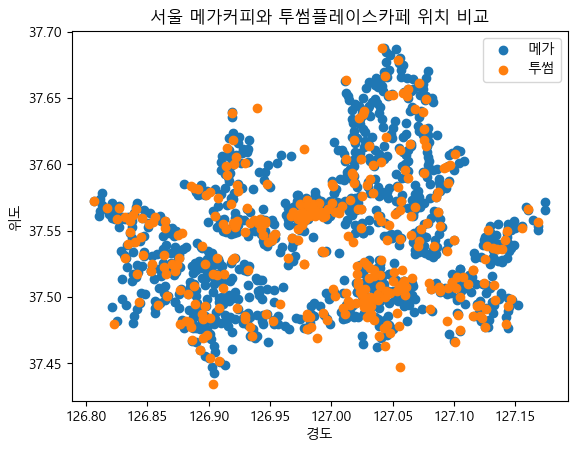

In [98]:
plt.scatter(df_mega['경도'], df_mega['위도'], label='메가')
plt.scatter(df_ts['경도'], df_ts['위도'], label= '투썸')
plt.legend()
plt.title('서울 메가커피와 투썸플레이스카페 위치 비교')
plt.xlabel('경도')
plt.ylabel('위도')
plt.show()

In [105]:
df_mega['브랜드'] = '메가커피'

In [101]:
df_mega

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도,브랜드
1903,MA010120220813183823,메가엠지씨커피수유,음식,비알코올,카페,강북구,수유1동,수유동,127.018013,37.630912,메가커피
2964,MA010120220812507366,메가MGC커피상암사보이시티점,음식,비알코올,카페,마포구,상암동,상암동,126.888542,37.581325,메가커피
3510,MA010120220809740316,메가엠지씨커피휘경주공점,음식,비알코올,카페,동대문구,장안2동,장안동,127.070394,37.580149,메가커피
3704,MA010120220803674019,메가엠지씨커피강동역점,음식,비알코올,카페,강동구,길동,길동,127.135229,37.535853,메가커피
5293,MA010120220803331542,메가엠지씨커피신용산역점,음식,비알코올,카페,용산구,한강로동,한강로2가,126.969996,37.531017,메가커피
...,...,...,...,...,...,...,...,...,...,...,...
534378,MA0106202511A0885817,메가엠지씨커피역삼센터필드점,음식,비알코올,카페,강남구,역삼1동,역삼동,127.040318,37.503605,메가커피
534550,MA0106202511A0887350,메가엠지씨커피,음식,비알코올,카페,동작구,신대방1동,신대방동,126.911457,37.494659,메가커피
534672,MA0106202511A2428196,메가엠지씨커피,음식,비알코올,카페,동대문구,장안2동,장안동,127.071053,37.570742,메가커피
534778,MA0106202511A1104238,메가엠지씨커피방배초교입구교차로점,음식,비알코올,카페,서초구,방배2동,방배동,126.985776,37.485537,메가커피


In [106]:
df_ts['브랜드'] = '투썸플레이스'

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15732\1666176404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['브랜드'] = '투썸플레이스'


In [107]:
df_ts

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도,브랜드
986,MA010120220804363123,투썸플레이스중계은행,음식,비알코올,카페,노원구,중계본동,중계동,127.076975,37.649233,투썸플레이스
7155,MA010120220805117484,투썸플레이스가락시장역,음식,비알코올,카페,송파구,가락본동,가락동,127.118858,37.493136,투썸플레이스
11506,MA010120220812696762,투썸플레이스세종대학교점,음식,비알코올,카페,광진구,군자동,군자동,127.073185,37.551613,투썸플레이스
12704,MA010120220808672564,투썸플레이스답십리사거리,음식,비알코올,카페,동대문구,답십리1동,답십리동,127.056600,37.572669,투썸플레이스
13137,MA010120220811794135,투썸플레이스,음식,비알코올,카페,중구,소공동,북창동,126.977476,37.562968,투썸플레이스
...,...,...,...,...,...,...,...,...,...,...,...
530192,MA0106202201A1168561,투썸플레이스,음식,비알코올,카페,강남구,신사동,신사동,127.026981,37.526197,투썸플레이스
530273,MA0106202201A1168548,투썸플레이스을지트윈,음식,비알코올,카페,중구,을지로동,을지로4가,126.997329,37.566141,투썸플레이스
531803,MA0106202511A2457802,투썸플레이스신림서원역점,음식,비알코올,카페,관악구,서원동,신림동,126.933693,37.477518,투썸플레이스
532385,MA0106202511A0716596,투썸플레이스가산대성디폴리스점,음식,비알코올,카페,금천구,가산동,가산동,126.877014,37.479951,투썸플레이스


In [108]:
pd.concat?

Signature:
pd.concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None,
) -> 'DataFrame | Series'
Docstring:
Concatenate pandas objects along a particular axis.

Allows optional set logic along the other axes.

Can also add a layer of hierarchical indexing on the concatenation axis,
which may be useful if the labels are the same (or overlapping) on
the passed axis number.

Parameters
----------
objs : a sequence or mapping of Series or DataFrame objects
    If a mapping is passed, the sorted keys will be used as the `keys`
    argument, unless it is passed, in which case the values will be
    selected (see below). Any None objects will be dropped silently unless
  

In [109]:
df_all  =  pd.concat([df_mega, df_ts])
df_all

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도,브랜드
1903,MA010120220813183823,메가엠지씨커피수유,음식,비알코올,카페,강북구,수유1동,수유동,127.018013,37.630912,메가커피
2964,MA010120220812507366,메가MGC커피상암사보이시티점,음식,비알코올,카페,마포구,상암동,상암동,126.888542,37.581325,메가커피
3510,MA010120220809740316,메가엠지씨커피휘경주공점,음식,비알코올,카페,동대문구,장안2동,장안동,127.070394,37.580149,메가커피
3704,MA010120220803674019,메가엠지씨커피강동역점,음식,비알코올,카페,강동구,길동,길동,127.135229,37.535853,메가커피
5293,MA010120220803331542,메가엠지씨커피신용산역점,음식,비알코올,카페,용산구,한강로동,한강로2가,126.969996,37.531017,메가커피
...,...,...,...,...,...,...,...,...,...,...,...
530192,MA0106202201A1168561,투썸플레이스,음식,비알코올,카페,강남구,신사동,신사동,127.026981,37.526197,투썸플레이스
530273,MA0106202201A1168548,투썸플레이스을지트윈,음식,비알코올,카페,중구,을지로동,을지로4가,126.997329,37.566141,투썸플레이스
531803,MA0106202511A2457802,투썸플레이스신림서원역점,음식,비알코올,카페,관악구,서원동,신림동,126.933693,37.477518,투썸플레이스
532385,MA0106202511A0716596,투썸플레이스가산대성디폴리스점,음식,비알코올,카페,금천구,가산동,가산동,126.877014,37.479951,투썸플레이스


<Axes: xlabel='경도', ylabel='위도'>

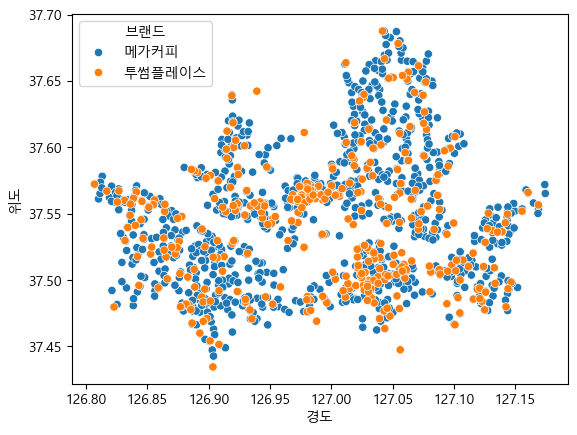

In [111]:
sns.scatterplot(data=df_all, x='경도', y='위도', hue='브랜드')

## folium 라이브러리 설치하기

In [112]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [113]:
import folium

In [114]:
df_mega['시군구명'] == '강남구'

1903      False
2964      False
3510      False
3704      False
5293      False
          ...  
534378     True
534550    False
534672    False
534778    False
534883    False
Name: 시군구명, Length: 921, dtype: bool

In [117]:
mega = df_mega[ df_mega['시군구명'] == '강남구']
mega

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도,브랜드
61209,MA010120220804461630,메가커피지하도점,음식,비알코올,카페,강남구,역삼1동,역삼동,127.028057,37.498617,메가커피
65917,MA010120220803359934,메가폰엔터테인먼트,음식,비알코올,카페,강남구,논현2동,논현동,127.040902,37.515408,메가커피
92724,MA010120220809653003,메가엠지씨커피대치,음식,비알코올,카페,강남구,대치4동,대치동,127.058503,37.502687,메가커피
154011,MA010120220804867315,메가엠지씨커피대치역점,음식,비알코올,카페,강남구,대치1동,대치동,127.062952,37.493882,메가커피
297088,MA010120220814137080,메가엠지씨커피대치학원가점,음식,비알코올,카페,강남구,대치4동,대치동,127.058738,37.498768,메가커피
...,...,...,...,...,...,...,...,...,...,...,...
527699,MA0106202510A1428798,메가엠지씨커피서울신구초점,음식,비알코올,카페,강남구,신사동,신사동,127.022976,37.523846,메가커피
528763,MA0106202511A1978743,메가엠지씨커피영동2교교차로점,음식,비알코올,카페,강남구,도곡2동,도곡동,127.043360,37.482728,메가커피
531202,MA0106202511A0455827,메가엠지씨커피포스코,음식,비알코올,카페,강남구,대치2동,대치동,127.057578,37.505868,메가커피
533677,MA0106202509A1101238,메가엠지씨커피학동,음식,비알코올,카페,강남구,청담동,청담동,127.039785,37.521860,메가커피


In [119]:
mega = mega.reset_index()
mega

,index,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구명,행정동명,법정동명,경도,위도,브랜드
0,61209,MA010120220804461630,메가커피지하도점,음식,비알코올,카페,강남구,역삼1동,역삼동,127.028057,37.498617,메가커피
1,65917,MA010120220803359934,메가폰엔터테인먼트,음식,비알코올,카페,강남구,논현2동,논현동,127.040902,37.515408,메가커피
2,92724,MA010120220809653003,메가엠지씨커피대치,음식,비알코올,카페,강남구,대치4동,대치동,127.058503,37.502687,메가커피
3,154011,MA010120220804867315,메가엠지씨커피대치역점,음식,비알코올,카페,강남구,대치1동,대치동,127.062952,37.493882,메가커피
4,297088,MA010120220814137080,메가엠지씨커피대치학원가점,음식,비알코올,카페,강남구,대치4동,대치동,127.058738,37.498768,메가커피
...,...,...,...,...,...,...,...,...,...,...,...,...
69,527699,MA0106202510A1428798,메가엠지씨커피서울신구초점,음식,비알코올,카페,강남구,신사동,신사동,127.022976,37.523846,메가커피
70,528763,MA0106202511A1978743,메가엠지씨커피영동2교교차로점,음식,비알코올,카페,강남구,도곡2동,도곡동,127.043360,37.482728,메가커피
71,531202,MA0106202511A0455827,메가엠지씨커피포스코,음식,비알코올,카페,강남구,대치2동,대치동,127.057578,37.505868,메가커피
72,533677,MA0106202509A1101238,메가엠지씨커피학동,음식,비알코올,카페,강남구,청담동,청담동,127.039785,37.521860,메가커피


In [120]:
mega['위도']

0     37.498617
1     37.515408
2     37.502687
3     37.493882
4     37.498768
        ...    
69    37.523846
70    37.482728
71    37.505868
72    37.521860
73    37.503605
Name: 위도, Length: 74, dtype: float64

In [122]:
mega['위도'][73]

np.float64(37.5036050403401)

In [126]:
map  = folium.Map(location= [ mega['위도'][0] ,    mega['경도'][0] ] )
map

In [125]:
folium.Marker(location=[  mega['위도'][0] ,    mega['경도'][0]], 
              tooltip=[mega['법정동명'][0] ] ).add_to(map)

In [127]:
for i in range(len(mega)):
    folium.Marker([mega['위도'][i], mega['경도'][i]]
              ,tooltip=mega['법정동명'][i]).add_to(map)

In [128]:
map

여러분 오늘 공부하면서 어떠했나요       
중간고사 기간 앞이라 수업의 양은 조금 줄였으나 새로운 내용들이 있었어요        
이러한 것도 있구나 하고 **경험하는 마음** 으로 공부하면 됩니다       
우리는 중간고사, 기말고사는 보지 않습니다    
**매주 여러분이 하는 실습과 피드백** , 토론활동, 기말프로젝트로 평가합니다       
즉 **매주 실습을 성실히**  하시면 되겠습니다     
참고로 8주차는 복습영상을 올리고 과제도 없으니 다른 교과의 중간고사에 전념하세요!!       
그럼 **아래의 셀에 어떻게 공부하였는지** 저에게 전해주세요 

In [ ]:
데이터 슬라이싱 과정에서 복사본 경고(SettingWithCopyWarning)가 발생했으나, .copy() 메서드를 활용해 문제를 해결했습니다.

In [ ]:
단순히 코드를 따라 치는 것을 넘어, 
위도/경도 기반의 지도 시각화까지 경험해 보며 데이터가 어떻게 쓰이는지 감을 잡을 수 있었습니다. 
꾸준히 복습하여 제 것으로 만들겠습니다.